# Stock Price Prediction using Linear Regression

In [13]:
%pip install scikit-learn pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Load and Prepare Data

In [15]:
df = pd.read_csv('data/cleaned_nifty50.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Select one stock for prediction
stock = 'ADANIENT.NS'
df_stock = df[df['Ticker'] == stock].copy().reset_index(drop=True)

print(f"Data for {stock}: {df_stock.shape}")
df_stock.head()

Data for ADANIENT.NS: (5810, 9)


,Date,Ticker,Company_Name,Sector,Open,High,Low,Close,Volume
0,2002-08-15 00:00:00+05:30,ADANIENT.NS,Adani Enterprises Ltd.,Infrastructure,-0.010749,-0.010749,-0.010749,-0.010749,0
1,2002-09-04 00:00:00+05:30,ADANIENT.NS,Adani Enterprises Ltd.,Infrastructure,0.050361,0.050522,0.049942,0.050103,478760
2,2002-09-05 00:00:00+05:30,ADANIENT.NS,Adani Enterprises Ltd.,Infrastructure,0.050522,0.050522,0.050007,0.050168,492461
3,2002-09-06 00:00:00+05:30,ADANIENT.NS,Adani Enterprises Ltd.,Infrastructure,0.050425,0.050425,0.049459,0.050071,510128
4,2002-09-09 00:00:00+05:30,ADANIENT.NS,Adani Enterprises Ltd.,Infrastructure,0.048331,0.049781,0.048331,0.049491,488272


# Feature Engineering

In [16]:
# Create lagged features
lags = 5
for i in range(1, lags+1):
    df_stock[f'lag_{i}'] = df_stock['Close'].shift(i)

# Add Volume (scaled or not)
df_stock['Volume_scaled'] = (df_stock['Volume'] - df_stock['Volume'].mean()) / df_stock['Volume'].std()

# Target: next day's Close (return)
df_stock['target'] = df_stock['Close'].shift(-1)

# Drop NaN
df_stock = df_stock.dropna()

# Features
features = [f'lag_{i}' for i in range(1, lags+1)] + ['Volume_scaled']
X = df_stock[features]
y = df_stock['target']

print(f"Features: {features}")
print(f"Data shape: {X.shape}")

Features: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'Volume_scaled']
Data shape: (5804, 6)


# Split into Train and Test

In [17]:
train_size = int(0.8 * len(X))
y_train, y_test = y[:train_size], y[train_size:]
X_train, X_test = X[:train_size], X[train_size:]

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (4643, 6), Test shape: (1161, 6)


# Train Linear Regression Model

In [18]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained.")

Model trained.


# Make Predictions

In [19]:
y_pred = model.predict(X_test)

MSE: 13803.467555
R2 Score: 0.9659


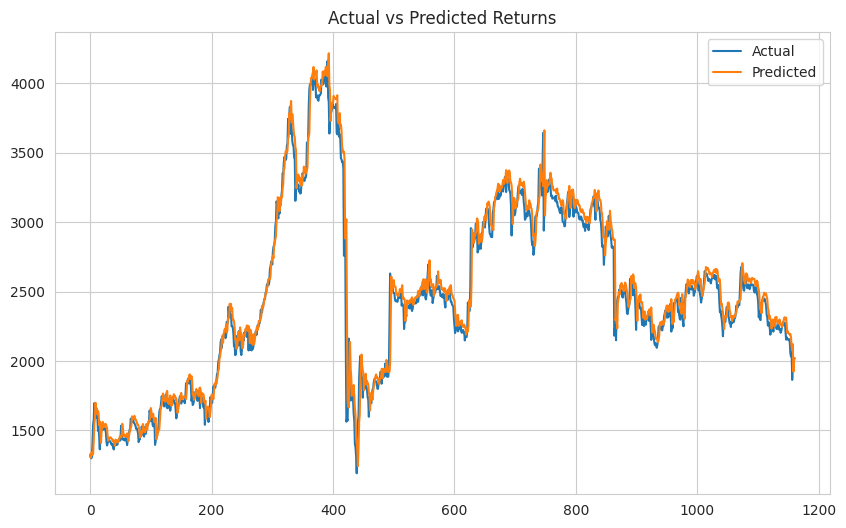

In [20]:
# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.6f}")
print(f"R2 Score: {r2:.4f}")

# Plot predictions vs actual
plt.figure(figsize=(10,6))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title('Actual vs Predicted Returns')
plt.show()